# Wasserstein-Distanz und Optimal Transport

Eine kurze Einführung in das Konzept, das in diesem Projekt zur Anomalieerkennung verwendet wird (siehe `scripts/analyse_data.py`).

## Was ist die Wasserstein-Distanz?

Die Wasserstein-Distanz (auch **Erdbewegungsdistanz** bzw. *Earth Mover's Distance*, EMD) ist ein Abstandsmaß zwischen zwei Wahrscheinlichkeitsverteilungen. Sie stammt aus der Theorie des **optimalen Transports** (*Optimal Transport*, OT), die ursprünglich auf den französischen Mathematiker Gaspard Monge (1781) zurückgeht und später von Leonid Kantorovich (1942) verallgemeinert wurde.

Die Grundidee lässt sich anschaulich als Erdbewegungsproblem beschreiben: Stellen wir uns zwei Verteilungen als Haufen von Sand oder Erde vor. Verteilung $P$ beschreibt, wie der Sand momentan verteilt liegt, Verteilung $Q$, wie er am Ende verteilt sein soll. Die Wasserstein-Distanz ist dann die minimale "Transportarbeit" (Masse × zurückgelegte Distanz), die nötig ist, um den einen Haufen in den anderen umzuformen.

Formal ist die Wasserstein-Distanz der Ordnung $p$ definiert als

$$
W_p(P, Q) = \left( \inf_{\gamma \in \Gamma(P,Q)} \int \|x - y\|^p \, d\gamma(x, y) \right)^{1/p}
$$

wobei $\Gamma(P,Q)$ die Menge aller "Transportpläne" (Kopplungen) ist, deren Randverteilungen $P$ bzw. $Q$ ergeben. Man sucht also über alle möglichen Arten, Masse von $P$ nach $Q$ zu verschieben, denjenigen Plan mit den geringsten Transportkosten.

Für den eindimensionalen Fall (wie in diesem Projekt, wo wir Spektren entlang der Frequenzachse vergleichen) vereinfacht sich die Berechnung erheblich: $W_1$ entspricht der Fläche zwischen den beiden kumulativen Verteilungsfunktionen (CDFs):

$$
W_1(P, Q) = \int_{-\infty}^{\infty} |F_P(x) - F_Q(x)| \, dx
$$

Genau dieses eindimensionale $W_1$ berechnet `scipy.stats.wasserstein_distance` — die Funktion, die in `scripts/analyse_data.py` durchgängig verwendet wird, um Spektren miteinander zu vergleichen.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, wasserstein_distance

rng = np.random.default_rng(42)
plt.rcParams["figure.dpi"] = 110

## Der Wasserstein-Mittelwert (Barycenter)

Ein einfaches, aber lehrreiches Beispiel zeigt, warum der optimale Transport eine grundlegend andere Vorstellung von "Mittelwert" liefert als die klassische arithmetische Mittelung.

Nehmen wir zwei Normalverteilungen, deren Peaks an den gegenüberliegenden Enden der x-Achse liegen — sie überlappen sich kaum.

- Das **arithmetische Mittel** zweier Dichten $p_1(x)$ und $p_2(x)$ ist einfach $\frac{1}{2}(p_1(x) + p_2(x))$ — punktweise gemittelt. Das Ergebnis ist zwangsläufig **bimodal**: zwei Hügel bleiben an ihren ursprünglichen Positionen stehen, nur halb so hoch. Das entspricht keiner realistischen "Zwischen"-Verteilung.
- Der **Wasserstein-Mittelwert** (auch *Wasserstein-Barycenter* oder *Fréchet-Mittelwert im Wasserstein-Raum*) ist dagegen diejenige Verteilung, die die Summe der quadrierten Wasserstein-Distanzen zu beiden Ausgangsverteilungen minimiert. Er entspricht der Verteilung, die "auf halbem Weg" entsteht, wenn man tatsächlich Masse von einer Verteilung zur anderen transportiert — für zwei eindimensionale Normalverteilungen $\mathcal{N}(\mu_1,\sigma_1^2)$ und $\mathcal{N}(\mu_2,\sigma_2^2)$ ist das exakt wieder eine Normalverteilung:

$$
\mathcal{N}\!\left(\frac{\mu_1+\mu_2}{2},\; \left(\frac{\sigma_1+\sigma_2}{2}\right)^2\right)
$$

Das Ergebnis ist **unimodal** — ein einzelner Peak genau in der Mitte. Die Masse wurde tatsächlich "verschoben", nicht nur überlagert.

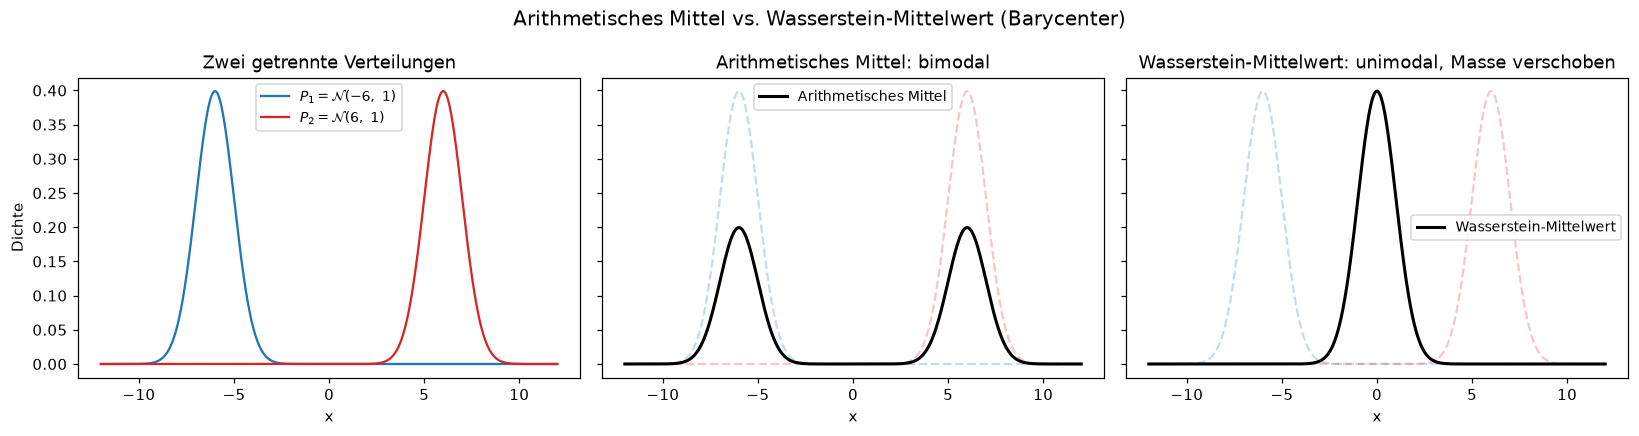

In [3]:
x = np.linspace(-12, 12, 1000)

mu1, sigma1 = -6, 1.0
mu2, sigma2 = 6, 1.0

pdf1 = norm.pdf(x, mu1, sigma1)
pdf2 = norm.pdf(x, mu2, sigma2)

arithmetic_mean = 0.5 * (pdf1 + pdf2)

barycenter_mu = 0.5 * (mu1 + mu2)
barycenter_sigma = 0.5 * (sigma1 + sigma2)
wasserstein_barycenter = norm.pdf(x, barycenter_mu, barycenter_sigma)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

axes[0].plot(x, pdf1, color="tab:blue", label=r"$P_1 = \mathcal{N}(-6,\ 1)$")
axes[0].plot(x, pdf2, color="tab:red", label=r"$P_2 = \mathcal{N}(6,\ 1)$")
axes[0].set_title("Zwei getrennte Verteilungen")
axes[0].legend(fontsize=9)

axes[1].plot(x, pdf1, color="tab:blue", alpha=0.25, linestyle="--")
axes[1].plot(x, pdf2, color="tab:red", alpha=0.25, linestyle="--")
axes[1].plot(x, arithmetic_mean, color="black", linewidth=2, label="Arithmetisches Mittel")
axes[1].set_title("Arithmetisches Mittel: bimodal")
axes[1].legend(fontsize=9)

axes[2].plot(x, pdf1, color="tab:blue", alpha=0.25, linestyle="--")
axes[2].plot(x, pdf2, color="tab:red", alpha=0.25, linestyle="--")
axes[2].plot(x, wasserstein_barycenter, color="black", linewidth=2, label="Wasserstein-Mittelwert")
axes[2].set_title("Wasserstein-Mittelwert: unimodal, Masse verschoben")
axes[2].legend(fontsize=9)

for ax in axes:
    ax.set_xlabel("x")
axes[0].set_ylabel("Dichte")

fig.suptitle("Arithmetisches Mittel vs. Wasserstein-Mittelwert (Barycenter)", fontsize=13)
plt.tight_layout()
plt.show()

## Die Wasserstein-Distanz als Abstandsmaß

Neben dem Mittelwert liefert der optimale Transport auch das eigentliche Abstandsmaß, das in diesem Projekt verwendet wird: Je näher sich zwei Verteilungen sind (weniger Transportarbeit nötig), desto kleiner die Wasserstein-Distanz — und umgekehrt.

Für zwei Verteilungen, die sich nur durch eine Verschiebung entlang der x-Achse unterscheiden (gleiche Form, unterschiedliche Lage), entspricht die $W_1$-Distanz exakt dem Abstand der Mittelwerte $|\mu_1 - \mu_2|$. Im Folgenden generieren wir Stichproben aus je zwei Normalverteilungen — einmal mit eng beieinander liegenden, einmal mit weit auseinander liegenden Peaks — und berechnen die Distanz mit genau der Funktion, die auch in `scripts/analyse_data.py` verwendet wird: `scipy.stats.wasserstein_distance`.

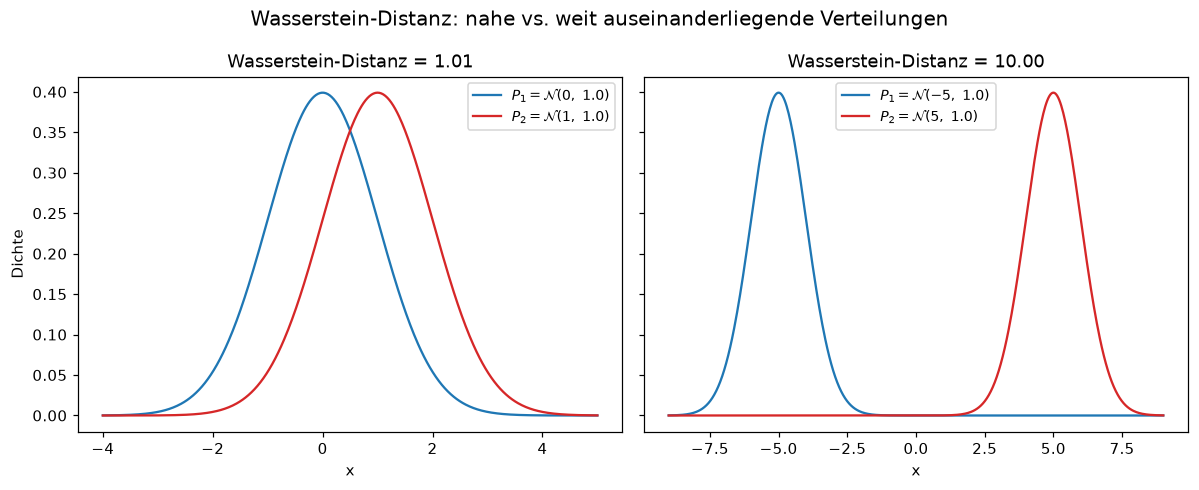

In [4]:
def plot_with_distance(ax, mu1, mu2, sigma=1.0, n=100_000):
    samples1 = rng.normal(mu1, sigma, n)
    samples2 = rng.normal(mu2, sigma, n)
    distance = wasserstein_distance(samples1, samples2)

    x = np.linspace(min(mu1, mu2) - 4 * sigma, max(mu1, mu2) + 4 * sigma, 500)
    ax.plot(x, norm.pdf(x, mu1, sigma), color="tab:blue", label=fr"$P_1 = \mathcal{{N}}({mu1},\ {sigma})$")
    ax.plot(x, norm.pdf(x, mu2, sigma), color="tab:red", label=fr"$P_2 = \mathcal{{N}}({mu2},\ {sigma})$")
    ax.set_title(f"Wasserstein-Distanz = {distance:.2f}")
    ax.set_xlabel("x")
    ax.legend(fontsize=9)
    return distance


fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

plot_with_distance(axes[0], mu1=0, mu2=1)
plot_with_distance(axes[1], mu1=-5, mu2=5)

axes[0].set_ylabel("Dichte")
fig.suptitle("Wasserstein-Distanz: nahe vs. weit auseinanderliegende Verteilungen", fontsize=13)
plt.tight_layout()
plt.show()

## Bezug zu diesem Projekt

In `scripts/analyse_data.py` wird genau dieses Konzept mehrfach genutzt:

- **`plot_connectivity_matrix`** berechnet für jede Sensor+Workstep-Gruppe das mittlere dB-Spektrum und bildet daraus eine paarweise Distanzmatrix — jedes Spektrum wird dabei als Massenverteilung über der Frequenzachse behandelt (Gewicht = Amplitude).
- **`compute_shape_anomaly_scores`** vergleicht jedes einzelne gemessene Spektrum mit dem Mittelwert seiner eigenen Gruppe; ungewöhnlich große Distanzen markieren "auffällige" Messungen, die als Grundlage für das Anomalie-Label dienen, mit dem später ein Klassifikator trainiert wird.

Die Wasserstein-Distanz eignet sich hier besonders gut, weil sie — anders als z. B. der punktweise quadratische Fehler — berücksichtigt, *wo* sich Energie im Spektrum befindet, nicht nur *wie viel*. Eine leichte Verschiebung eines Peaks wird dadurch als kleiner Unterschied bewertet, nicht als komplett andere Verteilung.